# Homework 3: PyTorch Compile Analysis

**Student:** Muhammad Fahad  
**Course:** CompSci 790  
**Notebook:** `torch_compile_analysis.ipynb`

This notebook follows the PyTorch programming section of the homework exactly:
1. backend comparison
2. debugging compilation failures
3. graph capture and inspection


In [ ]:
!pip -q install torch torchvision matplotlib pandas numpy tabulate

In [ ]:
import os
import io
import time
import json
import contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch._dynamo as dynamo

OUT_DIR = "figures"
os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch version:", torch.__version__)
print("Device:", device)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 12,
    "savefig.bbox": "tight"
})

PyTorch version: 2.10.0+cu128
Device: cuda


## Helper functions

In [ ]:
def sync_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def benchmark(fn, warmup=10, iters=100):
    for _ in range(warmup):
        fn()
    sync_device()
    times = []
    for _ in range(iters):
        t0 = time.perf_counter()
        fn()
        sync_device()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times))

def safe_compile(obj, **kwargs):
    try:
        return torch.compile(obj, **kwargs)
    except Exception as e:
        print("compile failed:", type(e).__name__, e)
        return None

## Part 1: Comparing Backends

Requirements covered:
- 3 linear layers with ReLU activations
- backends `eager`, `aot_eager`, `inductor`, and `cudagraphs`
- forward + backward pass repeated 100 times
- average timing bar chart
- discussion of tradeoffs

In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, in_dim=1024, hidden=2048, out_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, out_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

batch_size = 256
x = torch.randn(batch_size, 1024, device=device)
target = torch.randn(batch_size, 512, device=device)

candidate_backends = ["eager", "aot_eager", "inductor", "cudagraphs"]
backend_rows = []

for backend in candidate_backends:
    print(f"\nTesting backend: {backend}")
    model = SimpleMLP().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    if backend == "eager":
        compiled_model = model
        status = "ok"
    else:
        try:
            compiled_model = torch.compile(model, backend=backend)
            status = "ok"
        except Exception as e:
            compiled_model = None
            status = f"unavailable: {type(e).__name__}: {e}"

    if compiled_model is None:
        backend_rows.append({
            "backend": backend,
            "status": status,
            "first_call_s": np.nan,
            "avg_step_s": np.nan
        })
        continue

    def step():
        optimizer.zero_grad(set_to_none=True)
        out = compiled_model(x)
        loss = F.mse_loss(out, target)
        loss.backward()
        optimizer.step()
        return loss

    sync_device()
    t0 = time.perf_counter()
    first_loss = step()
    sync_device()
    first_call_s = time.perf_counter() - t0

    avg_step_s = benchmark(step, warmup=10, iters=100)

    backend_rows.append({
        "backend": backend,
        "status": status,
        "first_call_s": first_call_s,
        "avg_step_s": avg_step_s
    })

df_backend = pd.DataFrame(backend_rows)
display(df_backend)
df_backend.to_csv(f"{OUT_DIR}/torch_part1_backend_results.csv", index=False)


Testing backend: eager

Testing backend: aot_eager

Testing backend: inductor

Testing backend: cudagraphs


skipping cudagraphs due to skipping cudagraphs due to cpu device (primals_1). Found from : 
   File "/tmp/ipykernel_367/3918772620.py", line 9, in forward
    x = F.relu(self.fc1(x))



,backend,status,first_call_s,avg_step_s
0,eager,ok,0.492220,0.218808
1,aot_eager,ok,2.585370,0.215569
2,inductor,ok,18.438672,0.201817
3,cudagraphs,ok,0.431910,0.206768


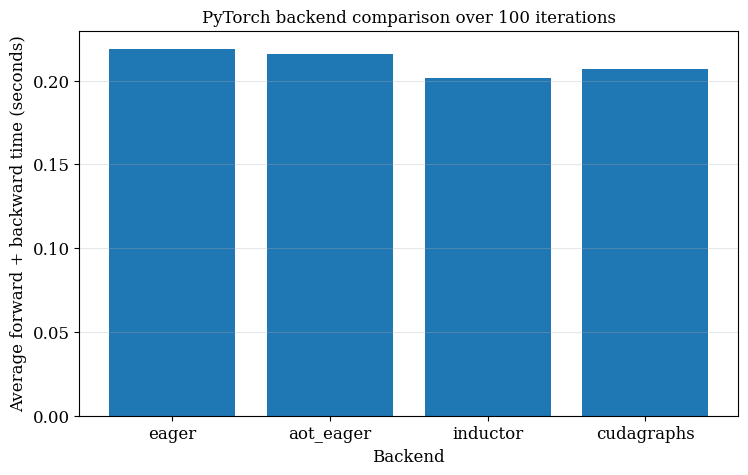

In [ ]:
plot_df = df_backend.dropna(subset=["avg_step_s"]).copy()

plt.figure(figsize=(8.5, 5.0))
plt.bar(plot_df["backend"], plot_df["avg_step_s"])
plt.xlabel("Backend")
plt.ylabel("Average forward + backward time (seconds)")
plt.title("PyTorch backend comparison over 100 iterations")
plt.grid(True, axis="y", alpha=0.3)
plt.savefig(f"{OUT_DIR}/torch_part1_backend_comparison.png", dpi=300)
plt.show()

## Part 2: Debugging Compilation Failures

Requirements covered:
- three problematic functions
- compile attempt for each
- `torch._dynamo.explain()` inspection
- efficient fixed version
- broken and fixed versions shown side by side

In [ ]:
def problem1(x):
    if x.sum() > 0:
        return x * 2
    else:
        return x / 2

def problem2(x):
    d = {}
    d["key"] = x
    return d["key"] * 2

def problem3(x):
    result = 0
    for i in range(10):
        result += (x ** i).sum()
    return result

def fixed_problem1(x):
    return torch.where(x.sum() > 0, x * 2, x / 2)

def fixed_problem2(x):
    # remove unnecessary Python container interaction
    return x * 2

def fixed_problem3(x):
    exponents = torch.arange(10, device=x.device, dtype=x.dtype).view(10, 1, 1)
    expanded = x.unsqueeze(0).pow(exponents)
    return expanded.sum()

sample = torch.randn(512, 512, device=device)

In [ ]:
problem_pairs = [
    ("problem1", problem1, fixed_problem1),
    ("problem2", problem2, fixed_problem2),
    ("problem3", problem3, fixed_problem3),
]

rows = []
full_explain = {}

for name, broken_fn, fixed_fn in problem_pairs:
    print(f"\n===== {name} =====")

    broken_status = "compiled"
    fixed_status = "compiled"

    try:
        compiled_broken = torch.compile(broken_fn)
        broken_out = compiled_broken(sample)
        if isinstance(broken_out, torch.Tensor):
            sync_device()
    except Exception as e:
        broken_status = f"failed: {type(e).__name__}: {e}"

    try:
        compiled_fixed = torch.compile(fixed_fn)
        fixed_out = compiled_fixed(sample)
        if isinstance(fixed_out, torch.Tensor):
            sync_device()
    except Exception as e:
        fixed_status = f"failed: {type(e).__name__}: {e}"

    try:
        explain_obj = dynamo.explain(broken_fn)(sample)
        explain_text = str(explain_obj)
    except Exception as e:
        explain_text = f"explain failed: {type(e).__name__}: {e}"

    full_explain[name] = explain_text
    print("Broken status:", broken_status)
    print("Fixed status:", fixed_status)
    print("Explain summary:")
    print(explain_text[:1500])

    rows.append({
        "function": name,
        "broken_status": broken_status,
        "fixed_status": fixed_status,
        "explain_summary": explain_text[:1200]
    })

df_problems = pd.DataFrame(rows)
display(df_problems)
df_problems.to_csv(f"{OUT_DIR}/torch_part2_debugging_results.csv", index=False)

with open(f"{OUT_DIR}/torch_part2_dynamo_explain.txt", "w") as f:
    for name, text in full_explain.items():
        f.write("=" * 80 + "\n")
        f.write(name + "\n")
        f.write("=" * 80 + "\n")
        f.write(text + "\n\n")


===== problem1 =====
Broken status: compiled
Fixed status: compiled
Explain summary:
Graph Count: 2
Graph Break Count: 1
Op Count: 2
Break Reasons:
  Break Reason 1:
    Reason: generic_jump TensorVariable()
    User Stack:
      <FrameSummary file /tmp/ipykernel_367/1739724488.py, line 2 in problem1>
Ops per Graph:
  Ops 1:
    <built-in function gt>
  Ops 2:
    <built-in function truediv>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create F

,function,broken_status,fixed_status,explain_summary
0,problem1,compiled,compiled,Graph Count: 2\nGraph Break Count: 1\nOp Count...
1,problem2,compiled,compiled,Graph Count: 1\nGraph Break Count: 0\nOp Count...
2,problem3,compiled,compiled,Graph Count: 1\nGraph Break Count: 0\nOp Count...


## Part 3: Graph Capture and Inspection

Requirements covered:
- two matrix multiplications
- ReLU
- residual connection
- layer normalization
- print statement
- Python list modification
- `torch.compile(..., fullgraph=True)`
- `torch._dynamo.explain()`
- FX style graph inspection
- diagram saved for the report

In [ ]:
def graph_function(x, w1, w2, ln_weight, ln_bias):
    y = x @ w1
    y = F.relu(y)
    y = y @ w2
    y = y + x
    y = F.layer_norm(y, normalized_shape=(y.shape[-1],), weight=ln_weight, bias=ln_bias)
    print("Hello")
    history = []
    history.append(int(y.shape[-1]))
    return y

d = 256
xg = torch.randn(32, d, device=device)
w1 = torch.randn(d, d, device=device)
w2 = torch.randn(d, d, device=device)
ln_weight = torch.ones(d, device=device)
ln_bias = torch.zeros(d, device=device)

In [ ]:
fullgraph_status = {"status": "unknown", "message": ""}

try:
    compiled_fullgraph = torch.compile(graph_function, fullgraph=True)
    capture_buffer = io.StringIO()
    with contextlib.redirect_stdout(capture_buffer):
        out = compiled_fullgraph(xg, w1, w2, ln_weight, ln_bias)
        sync_device()
    fullgraph_status["status"] = "compiled"
    fullgraph_status["message"] = capture_buffer.getvalue()
except Exception as e:
    fullgraph_status["status"] = "failed"
    fullgraph_status["message"] = f"{type(e).__name__}: {e}"

fullgraph_status

{'status': 'failed',
 'message': 'Unsupported: Failed to trace builtin operator\n  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types [\'str\'] (has_kwargs False)\n  Hint: Avoid calling builtin `print` with argument types [\'str\']. Consider using an equivalent alternative function/method to `print`.\n  Hint: If you are attempting to call a logging function (e.g. `print`), you can try adding it to `torch._dynamo.config.reorderable_logging_functions`.\n  Hint: Please report an issue to PyTorch.\n\n  Developer debug context: builtin print [<class \'torch._dynamo.variables.constant.ConstantVariable\'>] False\n\n For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb0059.html\n\nfrom user code:\n   File "/tmp/ipykernel_367/3401368314.py", line 7, in graph_function\n    print("Hello")\n\nSet TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do this especially if you\'re reporting 

In [ ]:
try:
    explain_capture = dynamo.explain(graph_function)(xg, w1, w2, ln_weight, ln_bias)
    explain_text = str(explain_capture)
except Exception as e:
    explain_text = f"dynamo explain failed: {type(e).__name__}: {e}"

with open(f"{OUT_DIR}/torch_part3_dynamo_explain.txt", "w") as f:
    f.write(explain_text)

print(explain_text[:4000])

Hello
Graph Count: 1
Graph Break Count: 0
Op Count: 5
Break Reasons:
  Break Reason 1:
    Reason: Failed to trace builtin operator
  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types ['str'] (has_kwargs False)
  Hint: Avoid calling builtin `print` with argument types ['str']. Consider using an equivalent alternative function/method to `print`.
  Hint: If you are attempting to call a logging function (e.g. `print`), you can try adding it to `torch._dynamo.config.reorderable_logging_functions`.
  Hint: Please report an issue to PyTorch.

  Developer debug context: builtin print [<class 'torch._dynamo.variables.constant.ConstantVariable'>] False

 For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb0059.html
    User Stack:
      <FrameSummary file /tmp/ipykernel_367/3401368314.py, line 7 in graph_function>
Ops per Graph:
  Ops 1:
    <built-in function matmul>
    <function relu at 

In [ ]:
# FX style IR for the tensor-only computational core
from torch.fx import symbolic_trace

class TensorOnlyCore(nn.Module):
    def forward(self, x, w1, w2, ln_weight, ln_bias):
        y = x @ w1
        y = F.relu(y)
        y = y @ w2
        y = y + x
        y = F.layer_norm(y, normalized_shape=(y.shape[-1],), weight=ln_weight, bias=ln_bias)
        return y

fx_model = TensorOnlyCore().to(device)
traced = symbolic_trace(fx_model)
print(traced.graph)

with open(f"{OUT_DIR}/torch_part3_fx_graph.txt", "w") as f:
    f.write(str(traced.graph))

graph():
    %x : [num_users=2] = placeholder[target=x]
    %w1 : [num_users=1] = placeholder[target=w1]
    %w2 : [num_users=1] = placeholder[target=w2]
    %ln_weight : [num_users=1] = placeholder[target=ln_weight]
    %ln_bias : [num_users=1] = placeholder[target=ln_bias]
    %matmul : [num_users=1] = call_function[target=operator.matmul](args = (%x, %w1), kwargs = {})
    %relu : [num_users=1] = call_function[target=torch.nn.functional.relu](args = (%matmul,), kwargs = {inplace: False})
    %matmul_1 : [num_users=1] = call_function[target=operator.matmul](args = (%relu, %w2), kwargs = {})
    %add : [num_users=2] = call_function[target=operator.add](args = (%matmul_1, %x), kwargs = {})
    %getattr_1 : [num_users=1] = call_function[target=builtins.getattr](args = (%add, shape), kwargs = {})
    %getitem : [num_users=1] = call_function[target=operator.getitem](args = (%getattr_1, -1), kwargs = {})
    %layer_norm : [num_users=1] = call_function[target=torch.nn.functional.layer_norm]

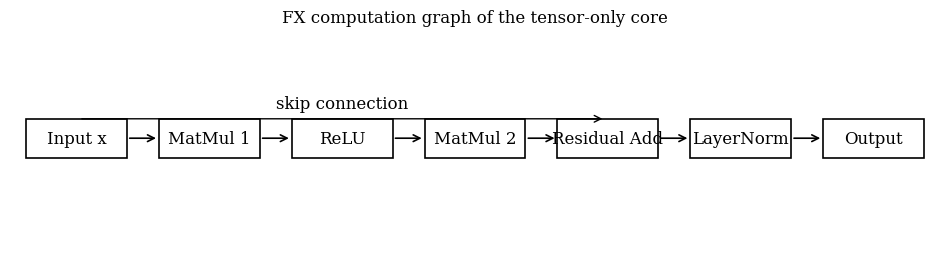

In [ ]:
# Create a clean computation graph diagram for the report
nodes = [
    "Input x",
    "MatMul 1",
    "ReLU",
    "MatMul 2",
    "Residual Add",
    "LayerNorm",
    "Output"
]

xpos = np.arange(len(nodes))
ypos = np.zeros(len(nodes))

plt.figure(figsize=(12, 2.8))
ax = plt.gca()
ax.set_xlim(-0.5, len(nodes) - 0.5)
ax.set_ylim(-1, 1)
ax.axis("off")

for i, node in enumerate(nodes):
    rect = plt.Rectangle((i - 0.38, -0.18), 0.76, 0.36, fill=False, linewidth=1.2)
    ax.add_patch(rect)
    ax.text(i, 0, node, ha="center", va="center")

for i in range(len(nodes) - 1):
    ax.annotate("", xy=(i + 0.62, 0), xytext=(i + 0.38, 0),
                arrowprops=dict(arrowstyle="->", lw=1.2))

# residual arrow from input to residual add
ax.annotate("", xy=(4 - 0.02, 0.18), xytext=(0 + 0.02, 0.18),
            arrowprops=dict(arrowstyle="->", lw=1.0))
ax.text(2, 0.32, "skip connection", ha="center", va="center")

plt.title("FX computation graph of the tensor-only core")
plt.savefig(f"{OUT_DIR}/torch_part3_fx_diagram.png", dpi=300)
plt.show()